# Lab 8: Part 2 of Pandas Introduction with Matplotlib
### Topic: Working with Experimental Data in Python

---
To begin, create a copy of this file using File -> Save as... and name the new file "Lab_8_LastName_FirstName.ipynb" using your last and first name.  Make sure to execute all the code cells in the notebook and that the outputs show in your report. *Two points are allocated for reading and running the code blocks*. Before submitting, remember to add a collaboration statement in this mark down indicating the contribution of each member. You may edit the template below:

- Rohit Bhogal - 011221171: Worked on all exercises as a group
- Neha Raj - 018968170: Worked on all exercises as a group
- Dania Abuirbaleh - 018756387: Went over exercises with group 

## Purpose of This Lab

In this lab, you will learn how to use **Pandas** and **Matplotlib**, two very important Python libraries used in science, engineering, healthcare, business, and data science.

By the end of this lab, you should be able to:

- understand what Pandas is and why people use it
- create and load a CSV file
- work with a **DataFrame**, which is a table of data in Python
- inspect data before analyzing it
- filter rows based on a condition
- group data and calculate averages
- create a new column based on rules
- make a simple bar chart using Matplotlib

---

## Big Idea

In real scientific work, data often follows a process like this:

**collect data → save data → load data → analyze data → graph data → interpret results**

That is exactly the workflow you will practice in this lab.


# Section 1: Core Pandas Workflow for Working with Tabular Data

By the end of this section, you should understand how to:

- import the libraries you need
- create a DataFrame
- inspect the data
- save the data as a CSV file
- load the CSV file back into Python

These are foundational skills you will use again and again in data analysis.

## Why this matters

In many college, lab, healthcare, business, and engineering settings, your data will not come in a perfect form.  
You often need to:

1. create or collect data  
2. check that it loaded correctly  
3. save it in a reusable format  
4. reload it later for analysis

That full process is a normal part of real data work.

## Importing Libraries for this lab

This lab uses two Python libraries:

- **Pandas**: used for working with tables of data
- **Matplotlib**: used for making graphs
You can run the next cell once before continuing or do manual installation in the terminal.


In [11]:
import sys
print("Python executable:", sys.executable)

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    
    print("✅ pandas version:", pd.__version__)
    print("✅ matplotlib loaded")

except ImportError as e:
    print("❌ Missing package:", e)
    print("👉 If you are using Anaconda, the packages should be installed automatically, so try reinstalling Anaconda.")
    print("👉 If you are using another package manager, follow the package installation instructions for that manager and your platform: e.g. for pip on windows, it would be: python -m pip install pandas matplotlib")


Python executable: /Users/rohit/anaconda3/bin/python
✅ pandas version: 2.3.3
✅ matplotlib loaded


## Example 1: Review of Pandas basics

To revisit the core ideas, we will use a small **campus wellness survey** dataset. Imagine a first-year college health office collected data on student sleep and stress during midterm week.

### Column meanings
- **Student_ID**: a unique student number
- **Hours_Slept**: hours of sleep the night before
- **Stress_Level**: a simple category reported by the student
- **Coffee_Cups**: number of cups of coffee that day

In [12]:
survey_data = {
    "Student_ID": [201, 202, 203, 204, 205, 206],
    "Hours_Slept": [7, 5, 6, 4, 8, 5],
    "Stress_Level": ["Medium", "High", "Medium", "High", "Low", "Medium"],
    "Coffee_Cups": [1, 3, 2, 4, 0, 2]
}

demo_df = pd.DataFrame(survey_data)
demo_df


,Student_ID,Hours_Slept,Stress_Level,Coffee_Cups
0,201,7,Medium,1
1,202,5,High,3
2,203,6,Medium,2
3,204,4,High,4
4,205,8,Low,0
5,206,5,Medium,2


## Inspecting the DataFrame

Before you analyze a dataset, you should always take a quick look at it.

This helps you answer questions like:

- Did the data load correctly?
- How many rows and columns are there?
- Are the column names spelled the way I expect?
- Does anything look unusual?


In [13]:
print(demo_df.head())
print(demo_df.shape)
print(demo_df.columns)


   Student_ID  Hours_Slept Stress_Level  Coffee_Cups
0         201            7       Medium            1
1         202            5         High            3
2         203            6       Medium            2
3         204            4         High            4
4         205            8          Low            0
(6, 4)
Index(['Student_ID', 'Hours_Slept', 'Stress_Level', 'Coffee_Cups'], dtype='object')


## Saving the Data as a CSV File

A **CSV** file stores data in rows and columns using plain text. CSV stands for **Comma-Separated Values**.

CSV files are common because they are:
- easy to share
- easy to open in Excel
- easy to load into Python
- widely used in science and data analysis


In [14]:
demo_df.to_csv("campus_wellness_survey.csv", index=False)


## Loading the CSV File Back Into Python

Now we will load the same file back into Python and store it in a DataFrame named `df`. This is important because many real datasets will come from files, not from dictionaries you type by hand.


In [15]:
df = pd.read_csv("campus_wellness_survey.csv")
df.head()


,Student_ID,Hours_Slept,Stress_Level,Coffee_Cups
0,201,7,Medium,1
1,202,5,High,3
2,203,6,Medium,2
3,204,4,High,4
4,205,8,Low,0


## What to Notice from this Workflow

In one section, you just practiced a complete beginner data workflow:

1. import libraries  
2. create a DataFrame  
3. inspect the data  
4. save it as a CSV  
5. load it again for analysis

That is exactly the kind of workflow you will use in later labs and real-world projects.


### Example 2

Now we will create an example dataset and save it as a file named `enzyme_plate.csv`. The dataset below is a simplified plate-reader style dataset.

### Column meanings
- **Well**: the position in the plate
- **Sample**: the sample or strain being tested
- **Treatment**: the condition applied
- **Replicate**: which repeat trial it is
- **OD600**: optical density measurement, often used as a rough indicator of cell growth

In [16]:
lab_data = {
    "Well": ["A1","A2","A3","B1","B2","B3","C1","C2","C3","D1","D2","D3","E1","E2","E3"],
    "Sample": [
        "Control","Control","Control",
        "Bacteria_A","Bacteria_A","Bacteria_A",
        "Bacteria_A","Bacteria_A","Bacteria_A",
        "Bacteria_B","Bacteria_B","Bacteria_B",
        "Bacteria_B","Bacteria_B","Bacteria_B"
    ],
    "Treatment": [
        "None","None","None",
        "Drug_A","Drug_A","Drug_A",
        "Drug_B","Drug_B","Drug_B",
        "Drug_A","Drug_A","Drug_A",
        "Drug_B","Drug_B","Drug_B"
    ],
    "Replicate": [1,2,3,1,2,3,1,2,3,1,2,3,1,2,3],
    "OD600": [
        0.12,0.10,0.11,
        0.65,0.72,0.68,
        0.35,0.37,0.33,
        0.80,0.76,0.79,
        0.41,0.39,0.43
    ]
}

df = pd.DataFrame(lab_data)
df.to_csv("enzyme_plate.csv", index=False)

print("CSV file created successfully.")


CSV file created successfully.


# Section 2: Filtering Data

A very common task in data analysis is selecting only the rows that meet a certain condition.

For example, if a high OD600 value suggests strong cell growth, we might want to find only the rows where:

```python
OD600 > 0.5
```

This is called **filtering**.


In [17]:
high_growth_demo = df[df["OD600"] > 0.5]
high_growth_demo


,Well,Sample,Treatment,Replicate,OD600
3,B1,Bacteria_A,Drug_A,1,0.65
4,B2,Bacteria_A,Drug_A,2,0.72
5,B3,Bacteria_A,Drug_A,3,0.68
9,D1,Bacteria_B,Drug_A,1,0.80
10,D2,Bacteria_B,Drug_A,2,0.76
11,D3,Bacteria_B,Drug_A,3,0.79


## How does filtering work?

Look at this pattern:

```python
df[df["OD600"] > 0.5]
```

Here is what it means:

- `df["OD600"]` selects the OD600 column
- `> 0.5` checks which values are greater than 0.5
- the outer `df[...]` keeps only the rows where that condition is true

This is a very powerful Pandas pattern and you will use it often.


# Section 3: Grouping Data and Calculating Averages

Another common data analysis task is comparing groups.

For example, we may want to know:

**What is the average OD600 for each treatment?**

To do that, we can group the data by the `Treatment` column and then calculate the mean of the `OD600` column.


In [18]:
treatment_means = df.groupby("Treatment")["OD600"].mean()
treatment_means


Treatment
Drug_A    0.733333
Drug_B    0.380000
None      0.110000
Name: OD600, dtype: float64

## What does that code mean?

```python
df.groupby("Treatment")["OD600"].mean()
```

Break it into parts:

- `groupby("Treatment")` → split the rows into groups based on treatment
- `["OD600"]` → focus on the OD600 column
- `.mean()` → calculate the average for each group

This gives a quick summary of how each treatment performed.


# Section 4: Creating a New Column from Rules

Sometimes raw numbers are easier to understand when we place them into categories.

For this example, we will use these rules:

- **Low** growth if `OD600 < 0.2`
- **Moderate** growth if `0.2 <= OD600 <= 0.5`
- **High** growth if `OD600 > 0.5`

To do this, we will write a function and apply it to every value in the OD600 column.


In [19]:
def classify_growth(od):
    if od < 0.2:
        return "Low"
    elif od <= 0.5:
        return "Moderate"
    else:
        return "High"

df["Growth_Level"] = df["OD600"].apply(classify_growth)
df.head()


,Well,Sample,Treatment,Replicate,OD600,Growth_Level
0,A1,Control,None,1,0.12,Low
1,A2,Control,None,2,0.10,Low
2,A3,Control,None,3,0.11,Low
3,B1,Bacteria_A,Drug_A,1,0.65,High
4,B2,Bacteria_A,Drug_A,2,0.72,High


## Why is this helpful?

Adding a category column can make data easier to discuss.

Instead of saying:

> “This well has an OD600 of 0.37”

we can also say:

> “This well shows moderate growth.”

That makes later counting and graphing easier too.


# Section 5: Visualizing Data with Pandas

Now that we have a category column, we can count how many wells fall into each group and then graph the result.


In [20]:
growth_counts = df["Growth_Level"].value_counts()
growth_counts


Growth_Level
High        6
Moderate    6
Low         3
Name: count, dtype: int64

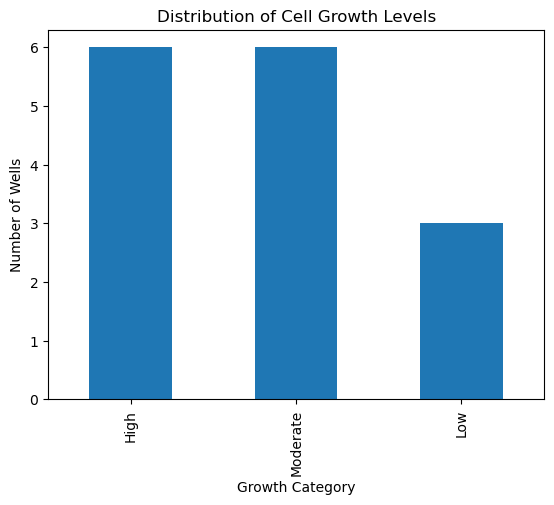

In [21]:
growth_counts.plot(kind="bar")

plt.title("Distribution of Cell Growth Levels")
plt.xlabel("Growth Category")
plt.ylabel("Number of Wells")

plt.show()


## What is happening here?

### `value_counts()`
Counts how many times each category appears.

### `plot(kind="bar")`
Makes a bar chart.

### `plt.title(...)`
Adds a title to the graph.

### `plt.xlabel(...)` and `plt.ylabel(...)`
Label the axes so the graph is easier to read.

These details matter because a graph should be clear and understandable to another person.


# Section 6: Merging DataFrames

In real datasets, information is often split across more than one table.

For example:

- one table might contain student survey results
- another table might contain attendance data
- another table might contain lab results

To combine related tables, we use **merging**.

A merge matches rows using a shared column.  
That shared column is often an ID number, such as `Student_ID`, `Patient_ID`, or `Sample_ID`.


## Example: Combine campus wellness survey dataset with attendance data

Below, we create a second dataset that tracks how many classes each student attended that week.

Notice that both tables contain `Student_ID`.  
That shared column is what makes the merge possible.


In [22]:
attendance_df = pd.DataFrame({
    "Student_ID": [201, 202, 203, 204, 205, 206],
    "Classes_Attended": [4, 3, 5, 2, 5, 4]
})

attendance_df


,Student_ID,Classes_Attended
0,201,4
1,202,3
2,203,5
3,204,2
4,205,5
5,206,4


In [23]:
merged_demo_df = pd.merge(demo_df, attendance_df, on="Student_ID")
merged_demo_df


,Student_ID,Hours_Slept,Stress_Level,Coffee_Cups,Classes_Attended
0,201,7,Medium,1,4
1,202,5,High,3,3
2,203,6,Medium,2,5
3,204,4,High,4,2
4,205,8,Low,0,5
5,206,5,Medium,2,4


## What happened here?

```python
pd.merge(demo_df, attendance_df, on="Student_ID")
```

This means:

- take `demo_df`
- take `attendance_df`
- match rows using the `Student_ID` column
- build one combined DataFrame

This is useful because it lets you bring related information together before analyzing it.


# Section 7: Handling Missing Data

Real data is often incomplete.

A missing value might happen because:

- someone skipped a survey question
- an instrument failed to record a value
- a sample was lost
- data entry was incomplete

In Pandas, missing values usually appear as `NaN`, which stands for **Not a Number**.


## Example: A dataset with missing values

In the example below, some students are missing values for sleep or coffee intake. This is very realistic. In actual data analysis, handling missing values is a normal step, not a sign that you did something wrong.


In [24]:
sleep_df = pd.DataFrame({
    "Student_ID": [201, 202, 203, 204, 205, 206],
    "Hours_Slept": [7, None, 6, 4, None, 5],
    "Coffee_Cups": [1, 3, None, 4, 0, 2]
})

sleep_df


,Student_ID,Hours_Slept,Coffee_Cups
0,201,7.0,1.0
1,202,NaN,3.0
2,203,6.0,NaN
3,204,4.0,4.0
4,205,NaN,0.0
5,206,5.0,2.0


## Detect missing values


In [25]:
sleep_df.isnull().sum()


Student_ID     0
Hours_Slept    2
Coffee_Cups    1
dtype: int64

## Fill missing values

One common strategy is to fill a missing numerical value with the column average. That is not always the best choice in advanced analysis, but it is a useful starting point for learning.


In [26]:
sleep_df["Hours_Slept"] = sleep_df["Hours_Slept"].fillna(sleep_df["Hours_Slept"].mean())
sleep_df["Coffee_Cups"] = sleep_df["Coffee_Cups"].fillna(sleep_df["Coffee_Cups"].mean())

sleep_df


,Student_ID,Hours_Slept,Coffee_Cups
0,201,7.0,1.0
1,202,5.5,3.0
2,203,6.0,2.0
3,204,4.0,4.0
4,205,5.5,0.0
5,206,5.0,2.0


## New worked example: merge first, then clean missing data

This final example shows a mini workflow you may see in real analysis:

1. combine two tables  
2. check for missing values  
3. fill the missing values  
4. summarize the result


In [27]:
wellness_with_missing = pd.DataFrame({
    "Student_ID": [201, 202, 203, 204, 205, 206],
    "Study_Hours": [2, 4, None, 5, 1, None]
})

combined_df = pd.merge(sleep_df, wellness_with_missing, on="Student_ID")

print("Missing values before cleaning:")
print(combined_df.isnull().sum())

combined_df["Study_Hours"] = combined_df["Study_Hours"].fillna(combined_df["Study_Hours"].mean())

print("\nMissing values after cleaning:")
print(combined_df.isnull().sum())

combined_df


Missing values before cleaning:
Student_ID     0
Hours_Slept    0
Coffee_Cups    0
Study_Hours    2
dtype: int64

Missing values after cleaning:
Student_ID     0
Hours_Slept    0
Coffee_Cups    0
Study_Hours    0
dtype: int64


,Student_ID,Hours_Slept,Coffee_Cups,Study_Hours
0,201,7.0,1.0,2.0
1,202,5.5,3.0,4.0
2,203,6.0,2.0,3.0
3,204,4.0,4.0,5.0
4,205,5.5,0.0,1.0
5,206,5.0,2.0,3.0


This kind of workflow is important because real analysis is not only about making graphs or calculating averages.

A lot of data work involves preparing the data so your later results are meaningful and easier to trust.


# STUDENT LAB EXCERCISES: CDC Mock Outbreak Investigation

You will now apply the same Pandas skills to a mock public health dataset.

In this section, you are assisting a fictional CDC investigation involving **Salmonella aeris**, a foodborne bacterium linked to contaminated packaged salads.

Hospitals across several western states reported patients with gastrointestinal illness. Investigators collected:

- patient demographics
- suspected exposure source
- bacterial load from laboratory samples
- hospitalization status
- symptom onset dates

Your goal is to use Pandas and Matplotlib to explore the outbreak


### Build the CDC case dataset

Just like earlier in the lab, we will begin with a Python dictionary, convert it into a DataFrame, save it as a CSV file, and then reload it for analysis.


In [28]:
cdc_cases = {
    "Case_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112],
    "State": ["CA", "CA", "NV", "NV", "OR", "OR", "WA", "WA", "CA", "NV", "OR", "WA"],
    "Age": [24, 45, 33, 51, 29, 62, 40, 36, 55, 22, 47, 31],
    "Exposure_Source": [
        "Packaged Salad", "Packaged Salad", "Restaurant Salad", "Packaged Salad",
        "Restaurant Salad", "Packaged Salad", "Restaurant Salad", "Packaged Salad",
        "Restaurant Salad", "Packaged Salad", "Restaurant Salad", "Packaged Salad"
    ],
    "Bacterial_Load_CFU": [1200, 1500, 800, 2000, 900, 2400, 1100, 1300, 1750, 950, 1400, 1000],
    "Hospitalized": ["Yes", "Yes", "No", "Yes", "No", "Yes", "No", "No", "Yes", "No", "Yes", "No"],
    "Symptom_Onset_Day": [1, 2, 2, 3, 4, 4, 5, 5, 6, 7, 7, 8]
}

cases_df = pd.DataFrame(cdc_cases)
cases_df.to_csv("cdc_outbreak_cases.csv", index=False)

print("CDC outbreak CSV file created successfully.")
cases_df


CDC outbreak CSV file created successfully.


,Case_ID,State,Age,Exposure_Source,Bacterial_Load_CFU,Hospitalized,Symptom_Onset_Day
0,101,CA,24,Packaged Salad,1200,Yes,1
1,102,CA,45,Packaged Salad,1500,Yes,2
2,103,NV,33,Restaurant Salad,800,No,2
3,104,NV,51,Packaged Salad,2000,Yes,3
4,105,OR,29,Restaurant Salad,900,No,4
5,106,OR,62,Packaged Salad,2400,Yes,4
6,107,WA,40,Restaurant Salad,1100,No,5
7,108,WA,36,Packaged Salad,1300,No,5
8,109,CA,55,Restaurant Salad,1750,Yes,6
9,110,NV,22,Packaged Salad,950,No,7


## Student exercises

Read each prompt carefully and write your code in the cell below each question.


### Exercise 1: Inspect the outbreak dataset (2 points)

Use the outbreak dataset stored in `cases_df`.

Instructions:

1. Load the data from the csv
2. Display the first 5 rows of the dataset.
3. Print the shape of the dataset.
4. Print the column names.

This exercise checks that you can inspect a DataFrame before beginning analysis.


In [ ]:
print(cases_df.head())
print(cases_df.shape)
list(cases_df.columns)


   Case_ID State  Age   Exposure_Source  Bacterial_Load_CFU Hospitalized  \
0      101    CA   24    Packaged Salad                1200          Yes   
1      102    CA   45    Packaged Salad                1500          Yes   
2      103    NV   33  Restaurant Salad                 800           No   
3      104    NV   51    Packaged Salad                2000          Yes   
4      105    OR   29  Restaurant Salad                 900           No   

   Symptom_Onset_Day  
0                  1  
1                  2  
2                  2  
3                  3  
4                  4  
(12, 7)


['Case_ID',
 'State',
 'Age',
 'Exposure_Source',
 'Bacterial_Load_CFU',
 'Hospitalized',
 'Symptom_Onset_Day']

### Exercise 2: Severe case investigation and exposure source analysis (3 points)

Investigators believe cases with **Bacterial_Load_CFU > 1700** may represent severe infections.

Instructions:

1. Create a DataFrame called `severe_cases` that contains only rows where `Bacterial_Load_CFU > 1700`.
2. Print the filtered dataset.
3. Group the original outbreak dataset by `Exposure_Source`.
4. Calculate the average `Bacterial_Load_CFU` for each exposure source.
5. Store the grouped result in a variable called `exposure_means`.
6. Print the result.

This exercise combines **filtering** and **grouped analysis**.


In [52]:
severe_cases = cases_df[cases_df["Bacterial_Load_CFU"] > 1700]
severe_cases

,Case_ID,State,Age,Exposure_Source,Bacterial_Load_CFU,Hospitalized,Symptom_Onset_Day
3,104,NV,51,Packaged Salad,2000,Yes,3
5,106,OR,62,Packaged Salad,2400,Yes,4
8,109,CA,55,Restaurant Salad,1750,Yes,6


### Exercise 3: Create an infection severity column (1 point)

Create a new column called `Infection_Severity` using the rules below:

- If `Bacterial_Load_CFU < 1000`, label it `"Mild"`
- If `1000 <= Bacterial_Load_CFU <= 1700`, label it `"Moderate"`
- If `Bacterial_Load_CFU > 1700`, label it `"Severe"`

Instructions:

1. Write a function that classifies one bacterial load value.
2. Use `.apply()` to create the new column.
3. Print the first few rows of the updated DataFrame.


In [91]:
def classify_bacteria_load(bl):
    if (bl < 1000):
        return "Mild"
    if (bl <= 1700):
        return 'Moderate'
    else:
        return "High"

cases_df["Infection_Severity"] = cases_df["Bacterial_Load_CFU"].apply(classify_bacteria_load)
cases_df.head()


,Case_ID,State,Age,Exposure_Source,Bacterial_Load_CFU,Hospitalized,Symptom_Onset_Day,Infection_Severity
0,101,CA,24,Packaged Salad,1200,Yes,1,Moderate
1,102,CA,45,Packaged Salad,1500,Yes,2,Moderate
2,103,NV,33,Restaurant Salad,800,No,2,Mild
3,104,NV,51,Packaged Salad,2000,Yes,3,High
4,105,OR,29,Restaurant Salad,900,No,4,Mild


### Exercise 4: Build a CDC-style epidemiological curve (1 point)

An **epidemiological curve**, or **epi curve**, shows how many cases occur on each day of an outbreak.

Instructions:

1. Count the number of cases for each `Symptom_Onset_Day`.
2. Plot a **bar chart** of those counts.
3. Add a title.
4. Add an x-axis label.
5. Add a y-axis label.
6. Display the graph.

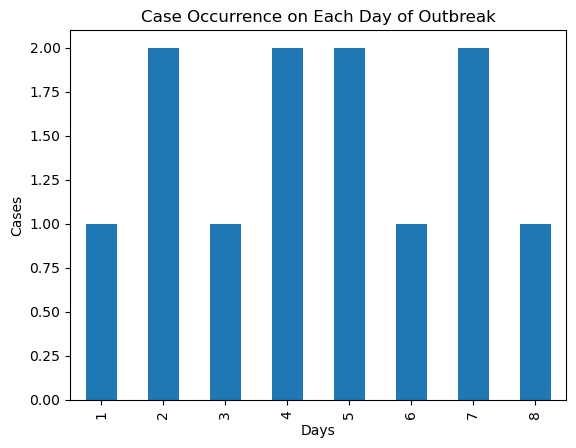

In [65]:
symptom_onset_day = cases_df["Symptom_Onset_Day"].value_counts().sort_index()
symptom_onset_day

symptom_onset_day.plot(kind="bar")

plt.title("Case Occurrence on Each Day of Outbreak")
plt.xlabel("Days")
plt.ylabel("Cases")

plt.show()

### Exercise 5: Patient Zero investigation (1 point)

A simple first step in an outbreak investigation is to identify the earliest known case.

Instructions:

1. Find the earliest value in `Symptom_Onset_Day`.
2. Determine which `Case_ID` appears first in the outbreak timeline.
3. Print the earliest onset day and the likely first case.

This may represent the **index case**, sometimes informally called **Patient Zero**.


In [89]:
earliest_day = cases_df[cases_df['Symptom_Onset_Day'] == cases_df['Symptom_Onset_Day'].min()]
print(earliest_day['Case_ID'])


0    101
Name: Case_ID, dtype: int64


## Submission checklist

Before submitting your notebook, make sure you have:

- run all cells
- fixed any errors
- included your graph
- labeled the axes on your graph
- saved your notebook
